
# Particle-hole bubble for the modified Hamiltonian

This notebook implements the static particle-hole bubble

$
\Pi(\mathbf q,0)=\int \frac{d^2k}{(2\pi)^2}\sum_{lm}
\left|\langle u_l(\mathbf k)|\tau_3\sigma_3|u_m(\mathbf k+\mathbf q)\rangle\right|^2
\frac{n_F[\xi_l(\mathbf k)]-n_F[\xi_m(\mathbf k+\mathbf q)]}
{\xi_l(\mathbf k)-\xi_m(\mathbf k+\mathbf q)}
$

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import time

from joblib import Parallel, delayed
# =========================
# Input parameters
# =========================
params = {
    "t": 1,
    "t_ap": -0.3,   # t_a'
    "t_bp": 0.2,    # t_b'
    "lam": 0.0,       # lambda
    "mu": 0.2,
}
beta = 100.0
Nk = 60
Nq = 80

# =========================
# Pauli matrices
# =========================
tau = {
    0: np.array([[1, 0], [0, 1]], dtype=complex),
    1: np.array([[0, 1], [1, 0]], dtype=complex),
    2: np.array([[0, -1j], [1j, 0]], dtype=complex),
    3: np.array([[1, 0], [0, -1]], dtype=complex),
}
sigma = {
    0: np.array([[1, 0], [0, 1]], dtype=complex),
    1: np.array([[0, 1], [1, 0]], dtype=complex),
    2: np.array([[0, -1j], [1j, 0]], dtype=complex),
    3: np.array([[1, 0], [0, -1]], dtype=complex),
}

def G(a, b):
    return np.kron(tau[a], sigma[b])

# Gamma matrices used by H0'(k)
Gamma1  = G(0, 0)
Gamma2  = G(3, 3)   # tau_3 sigma_3, the particle-hole vertex
Gamma3  = G(3, 0)
Gamma9  = G(2, 0)
Gamma10 = G(2, 3)
Gamma11 = G(1, 0)
Gamma12 = G(1, 3)

# =========================
# Hamiltonian H0'(k)
# =========================
# def Hk(kx, ky, p):
#     h0  = -(p["t_ap"] + p["t_bp"]) * (np.cos(kx) + np.cos(ky)) - p["mu"]
#     h3  = -(p["t_ap"] - p["t_bp"]) * (np.cos(kx) - np.cos(ky))
#     h11 = -4.0 * p["t"] * np.cos(0*(kx + ky)/2.0) * np.cos(kx/2.0) * np.cos(ky/2.0)
#     h12 =  4.0 * p["t"] * np.sin(0*(kx + ky)/2.0) * np.cos(kx/2.0) * np.cos(ky/2.0)
#     h21 =  p["lam"] * np.sin(0*(kx + ky)/2.0) * np.sin(kx/2.0) * np.sin(ky/2.0)
#     h22 =  p["lam"] * np.cos(0*(kx + ky)/2.0) * np.sin(kx/2.0) * np.sin(ky/2.0)

#     return (
#         h0[..., None, None]  * Gamma1
#         + h3[..., None, None]  * Gamma3
#         + h11[..., None, None] * Gamma11
#         + h12[..., None, None] * Gamma9
#         + h21[..., None, None] * Gamma12
#         + h22[..., None, None] * Gamma10
#     )

# def Hk(kx, ky, p):
#     h0  = -(p["t_ap"] + p["t_bp"]) * (np.cos(kx) + np.cos(ky)) - p["mu"]
#     h3  = -(p["t_ap"] - p["t_bp"]) * (np.cos(kx) - np.cos(ky))
#     h11 = -4.0 * p["t"] * np.cos((kx + ky)/2.0) * np.cos(kx/2.0) * np.cos(ky/2.0)
#     h12 =  4.0 * p["t"] * np.sin((kx + ky)/2.0) * np.cos(kx/2.0) * np.cos(ky/2.0)
#     h21 =  p["lam"] * np.sin((kx + ky)/2.0) * np.sin(kx/2.0) * np.sin(ky/2.0)
#     h22 =  p["lam"] * np.cos((kx + ky)/2.0) * np.sin(kx/2.0) * np.sin(ky/2.0)

#     return (
#         h0[..., None, None]  * Gamma1
#         + h3[..., None, None]  * Gamma3
#         + h11[..., None, None] * Gamma11
#         + h12[..., None, None] * Gamma9
#         + h21[..., None, None] * Gamma12
#         + h22[..., None, None] * Gamma10
#     )

def Hk(kx, ky, p):
    h0  = -2*(p["t_ap"] + p["t_bp"]) * ( np.cos(kx) * np.cos(ky) ) - p["mu"]
    h3  = 2*(p["t_ap"] - p["t_bp"]) * ( np.sin(kx) * np.sin(ky) )
    h11 = -2 * p["t"] * ( np.cos(kx) + np.cos(ky) )
    h22 =  (p["lam"]/2) *  ( np.cos(ky) - np.cos(kx) )

    return (
        h0[..., None, None]  * Gamma1
        + h3[..., None, None]  * Gamma3
        + h11[..., None, None] * Gamma11
        + h22[..., None, None] * Gamma10
    )

# =========================
# Stable Fermi function
# =========================s
def fermi(E, beta):
    E = np.asarray(E, dtype=float)
    x = beta * E
    out = np.empty_like(x, dtype=float)

    pos = x >= 0.0
    out[pos] = np.exp(-x[pos]) / (1.0 + np.exp(-x[pos]))
    ex = np.exp(x[~pos])
    out[~pos] = 1.0 / (1.0 + ex)
    return out

def fermi_diff_quotient(E1, E2, beta, atol=1e-12, rtol=1e-10):
    """
    Computes [n_F(E1)-n_F(E2)]/(E1-E2), using the derivative limit
    when E1 ~= E2.
    """
    E1, E2 = np.broadcast_arrays(np.asarray(E1, dtype=float), np.asarray(E2, dtype=float))
    dE = E1 - E2

    f1 = fermi(E1, beta)
    f2 = fermi(E2, beta)

    out = np.empty_like(dE, dtype=float)
    tol = atol + rtol * np.maximum(np.abs(E1), np.abs(E2))
    regular = np.abs(dE) > tol

    out[regular] = (f1[regular] - f2[regular]) / dE[regular]

    Em = 0.5 * (E1[~regular] + E2[~regular])
    fm = fermi(Em, beta)
    out[~regular] = -beta * fm * (1.0 - fm)
    return out

# =========================
# k-grid in [-pi, pi)
# endpoint=False avoids double counting -pi and +pi on a periodic grid
# =========================
k_vals = np.linspace(-2*np.pi, 2*np.pi, Nk, endpoint=False)
kx_mesh, ky_mesh = np.meshgrid(k_vals, k_vals, indexing="ij")
kx_list = kx_mesh.ravel()
ky_list = ky_mesh.ravel()

# For a uniform grid on [-pi,pi)x[-pi,pi):
# d^2k/(2pi)^2 -> (Delta k)^2/(2pi)^2 = 1/Nk^2
wk = 1.0 / (Nk * Nk)

# Precompute eigensystem at k once
evals_k, evecs_k = np.linalg.eigh(Hk(kx_list, ky_list, params))

# =========================
# Static particle-hole bubble Pi(q,0), Eq. (75)
# =========================
def bubble_q(qx, qy):
    evals_kq, evecs_kq = np.linalg.eigh(Hk(kx_list + qx, ky_list + qy, params))

    # M_lm(k,q) = <u_l(k) | tau_3 sigma_3 | u_m(k+q)>
    M = np.matmul(np.matmul(np.swapaxes(evecs_k.conj(), -1, -2), Gamma2), evecs_kq)

    # [n_F(E_l(k)) - n_F(E_m(k+q))] / [E_l(k) - E_m(k+q)]
    F = fermi_diff_quotient(evals_k[:, :, None], evals_kq[:, None, :], beta)

    Pi = wk * np.sum(np.abs(M)**2 * F)
    return np.real_if_close(Pi).real

# =========================
# q-grid in [-pi, pi)
# =========================
q_vals = np.linspace(-2*np.pi, 2*np.pi, Nq, endpoint=False)
Pi_q = np.empty((Nq, Nq), dtype=float)   # Pi_q[iqx, iqy] = Pi(qx_i, qy_j)

# start = time.time()
# for iqx, qx in enumerate(q_vals):
#     for iqy, qy in enumerate(q_vals):
#         Pi_q[iqx, iqy] = bubble_q(qx, qy)
# print(f"Done in {time.time() - start:.2f} s")

start = time.time()

Pi_list = Parallel(n_jobs=24)(
    delayed(bubble_q)(qx, qy)
    for qx in q_vals
    for qy in q_vals
)

Pi_q = np.array(Pi_list).reshape(Nq, Nq)

print(f"Done in {time.time() - start:.2f} s")

# q=(0,0) is included because Nq is even
izero = Nq // 2
print("q-grid value at Nq//2 =", q_vals[izero])
print("Pi(q=0,0) =", Pi_q[izero, izero])
print("Pi_q shape =", Pi_q.shape)

Done in 7.47 s
q-grid value at Nq//2 = 0.0
Pi(q=0,0) = -1.4020912868490887
Pi_q shape = (80, 80)


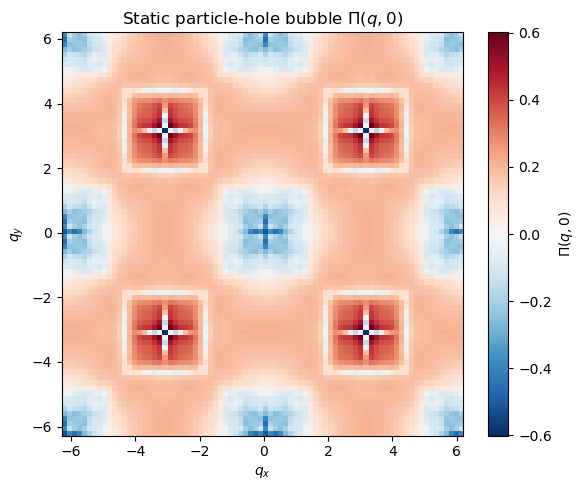

In [20]:
# =========================
# Plot
# =========================

Pi_qp=Pi_q-(np.max(Pi_q)+np.min(Pi_q))/2
vmax = np.max(Pi_qp)
vmin = np.min(Pi_qp)

plt.figure(figsize=(6, 5))
plt.imshow(
    Pi_qp.T,
    origin="lower",
    extent=[q_vals[0], q_vals[-1] + 2*np.pi/Nq, q_vals[0], q_vals[-1] + 2*np.pi/Nq],
    aspect="auto",
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax
)
plt.xlabel(r"$q_x$")
plt.ylabel(r"$q_y$")
plt.title(r"Static particle-hole bubble $\Pi(q,0)$")
plt.colorbar(label=r"$\Pi(q,0)$")
plt.tight_layout()
plt.show()

In [25]:
# =========================
# Build q-grid (same as before)
# =========================
qx_mesh, qy_mesh = np.meshgrid(q_vals, q_vals, indexing="ij")

# =========================
# Define symmetry-adapted 2π-periodic basis
# (A1g-dominated, physically clean)
# =========================
basis = {
    "1": np.ones_like(qx_mesh),

    "cos(qx)+cos(qy)": np.cos(qx_mesh) + np.cos(qy_mesh),
    
    "cos(qx)-cos(qy)": np.cos(qx_mesh) - np.cos(qy_mesh),

    "cos(qx)cos(qy)": np.cos(qx_mesh) * np.cos(qy_mesh),

    "sin(qx)sin(qy)": np.sin(qx_mesh) * np.sin(qy_mesh),

    "cos(2qx)+cos(2qy)": np.cos(2*qx_mesh) + np.cos(2*qy_mesh),

    "cos(2qx)cos(2qy)": np.cos(2*qx_mesh) * np.cos(2*qy_mesh),
}

# =========================
# Flatten data
# =========================
Pi_vec = Pi_q.ravel()

B = []
names = []

for name, f in basis.items():
    B.append(f.ravel())
    names.append(name)

B = np.stack(B, axis=1)

# =========================
# Least-squares fit
# =========================
coeffs, *_ = np.linalg.lstsq(B, Pi_vec, rcond=None)

# =========================
# Print coefficients (non-scientific format)
# =========================
print("\nExpansion coefficients (symmetry basis):\n")
for name, c in zip(names, coeffs):
    print(f"{name:25s} : {c:10.6f}")

# =========================
# Reconstruction + error
# =========================
Pi_fit = (B @ coeffs).reshape(Pi_q.shape)
error = np.linalg.norm(Pi_q - Pi_fit) / np.linalg.norm(Pi_q)

print(f"\nRelative fit error: {error:.3e}")


Expansion coefficients (symmetry basis):

1                         :  -0.776676
cos(qx)+cos(qy)           :  -0.117310
cos(qx)-cos(qy)           :   0.000000
cos(qx)cos(qy)            :  -0.107332
sin(qx)sin(qy)            :   0.000000
cos(2qx)+cos(2qy)         :  -0.005564
cos(2qx)cos(2qy)          :   0.014959

Relative fit error: 1.014e-01


In [95]:
0.245525/0.759705

0.32318465720246675

In [72]:
0.001369/0.761420

0.0017979564497911796